# 04. StateGraph 기초

> `StateGraph` = State + Node + Edge — 이 셋만 알면 LangGraph의 절반은 끝난 거예요. 가장 작은 그래프를 직접 만들며 핵심 어휘를 익혀요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `StateGraph`의 세 가지 핵심 구성 요소(State, Node, Edge)를 설명하고 직접 구현할 수 있어요
2. `TypedDict`로 상태 스키마를 정의하고, 기본 덮어쓰기 vs `Annotated` 리듀서의 차이를 이해해요
3. 일반 엣지와 조건부 엣지로 실행 흐름을 제어하고, `START`/`END` 특수 노드를 활용할 수 있어요
4. `Send`로 동적 병렬 처리를 구현하고, `Command`로 상태 업데이트와 라우팅을 동시에 처리할 수 있어요
5. 재귀 제한(`recursion_limit`)과 `GraphRecursionError`를 이해하고 안전한 그래프를 설계할 수 있어요

## 사전 지식

- Python `TypedDict`, `Annotated` 타입 힌트 기초
- 이전 노트북: `03-Messages.ipynb` — HumanMessage, AIMessage, ToolMessage 등 메시지 타입
- `add_messages` 리듀서 개념 (이전 노트북에서 소개됨)


## StateGraph란?

LangGraph의 핵심은 에이전트 워크플로우를 **그래프(Graph)**로 모델링하는 거예요. 그래프는 세 가지 핵심 구성 요소로 이루어져 있어요.

| 구성 요소 | 역할 | 핵심 특징 |
|----------|------|----------|
| **State (상태)** | 그래프 전체에서 공유되는 데이터 구조 | `TypedDict`로 스키마 정의, 리듀서로 업데이트 방식 지정 |
| **Nodes (노드)** | 실제 작업을 수행하는 Python 함수 | 현재 State를 입력받아 업데이트 딕셔너리 반환 |
| **Edges (엣지)** | 노드 간 실행 흐름 정의 | 일반 엣지(고정), 조건부 엣지(동적 분기) |

```mermaid
flowchart TB
    S([시작<br/>START]):::input
    N1[노드 A<br/>Node A]:::process
    N2[노드 B<br/>Node B]:::process
    N3[노드 C<br/>Node C]:::process
    E([종료<br/>END]):::output
    ST[(State<br/>공유 상태)]:::storage

    S --> N1
    N1 --> N2
    N1 -->|조건부| N3
    N2 --> E
    N3 --> E
    N1 <-.읽기/쓰기.-> ST
    N2 <-.읽기/쓰기.-> ST
    N3 <-.읽기/쓰기.-> ST

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

> 🔑 **핵심 개념**: StateGraph의 핵심은 **State가 노드들 사이를 흐르는 공유 메모리** 라는 점이에요. 공장의 조립 라인을 상상해보세요. 제품(State)이 컨베이어 벨트(Edge)를 타고 각 작업대(Node)를 거치면서 점점 완성되어 가는 거예요. 각 작업대는 제품의 특정 부분만 작업하고, 나머지는 그대로 다음 작업대로 넘겨요. 각 노드는 State를 읽고 일부를 업데이트하며, 엣지가 다음에 실행할 노드를 결정해요.


## 환경 설정


In [1]:
# 환경 변수 로드 (OPENAI_API_KEY 등)
from dotenv import load_dotenv

load_dotenv()


True

In [2]:
import os

# LangSmith 추적 설정 (선택 사항)
# 실행 과정을 LangSmith에서 시각적으로 디버깅할 수 있어요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-StateGraph"


## 1. 첫 번째 StateGraph 만들기

StateGraph를 만드는 기본 흐름은 항상 같아요:

1. **State 정의** → `TypedDict`로 공유 데이터 구조 설계
2. **Node 함수 작성** → State를 입력받아 업데이트 딕셔너리 반환
3. **Graph 조립** → `StateGraph` 생성 후 노드/엣지 추가
4. **compile()** → 실행 가능한 형태로 변환
5. **invoke()** → 초기 State를 넣어 실행


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Step 1 : State 정의
class SimpleState(TypedDict):
    input: str # 처리할 입력 텍스트
    result: str

# Step 2 : Node 정의
#  node는 그냥 일반적인 파이썬 함수
#  입력 : State, 출력 : State
def process_node(state: SimpleState):
    """입력값을 처리해 결과를 반환하는 노드"""

    return {"result": f"😍{state['input']}😀"}

# Step 3 : Graph 조립
builder = StateGraph(SimpleState)

# Step 3-1 : 노드 배치
builder.add_node("process", process_node)

# Step 3-2 : 엣지 연결
# START / END : 그래프의 진입점/종료점을 나타내는 특수한 노드
# add_edge( 출발 노드 , 목적지 노드 )
builder.add_edge(START, "process")
builder.add_edge("process", END)

# Step 4: compile() 을 통한 실행 가능한 상태로 만들기
graph = builder.compile()

/Users/mhso/working/lecture/hankyung/01-langgraph/.venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


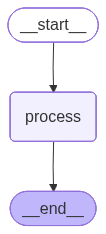

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# Step 5: invoke() - 초기 State를 넣어서 실행.
#  그래프의 노드를 통과하면서 State를 업데이트 한다라는 생각을 가져야 함.

# 초기 State 딕셔너리를 전달하면 START 부터 END 까지 노드를 순서대로 실행한다.
result = graph.invoke({"input": "안녕하세요!"})
result

{'input': '안녕하세요!', 'result': '😍안녕하세요!😀'}

## 2. State와 리듀서(Reducer)

State에서 가장 중요한 개념 중 하나가 **리듀서(Reducer)**예요. 노드가 State를 업데이트할 때 그 값을 어떻게 합칠지 결정해요.

| 리듀서 방식 | 선언 방법 | 동작 | 사용 예시 |
|------------|---------|------|----------|
| 기본 덮어쓰기 | 타입만 선언 | 새 값이 기존 값 완전 교체 | 단순 문자열, 숫자 |
| 커스텀 리듀서 | `Annotated[list, operator.add]` | 새 리스트가 기존 리스트에 추가 | 로그, 중간 결과 목록 |
| `add_messages` | `Annotated[list, add_messages]` | 메시지 추가 (ID 중복 시 업데이트) | 대화 이력 관리 |


### 2-1. 기본 덮어쓰기 리듀서

리듀서를 지정하지 않으면 새 값이 기존 값을 완전히 교체해요.


In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# 리듀서를 지정하지 않은 State - 모든 필드가 덮어쓰기 방식으로 업데이트 된다.
class OverwriteState(TypedDict):
    count: int
    label: str

def node_a(state: OverwriteState):
    """count를 10으로 업데이트, label은 건드리지 않아요"""
    print(f"  [node_a 진입] count={state['count']}, label={state['label']}")
    return {"count": state["count"] * 2}  # count만 반환, label은 유지돼요


def node_b(state: OverwriteState):
    """label을 업데이트, count는 건드리지 않아요"""
    print(f"  [node_b 진입] count={state['count']}, label={state['label']}")
    return {"label": "완료"}  # label만 반환, count는 유지돼요

# 그래프 구성
builder = StateGraph(OverwriteState)

# 그래프에 노드 추가
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)

# 노드 간 엣지 추가.
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

# 컴파일
graph = builder.compile()

# 초기 상태 값 집어 넣고 실행
result = graph.invoke({"count": 5, "label": "진행 중"})
result

  [node_a 진입] count=5, label=진행 중
  [node_b 진입] count=10, label=진행 중


{'count': 10, 'label': '완료'}

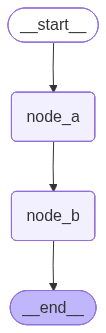

In [7]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### 2-2. 커스텀 리듀서 — 리스트 누적


In [8]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END

class AccumulateState(TypedDict):
    step: int # 누적이 필요 없음.
    log: Annotated[list[str], add] # add : add(a, b) -> a+b

def step_one(state: AccumulateState):
    """첫 번째 처리 단계"""
    return {
        "step": 1,
        "log": ["step_one 실행"]  # 기존 log 리스트에 추가돼요
    }


def step_two(state: AccumulateState):
    """두 번째 처리 단계"""
    return {
        "step": 2,
        "log": ["step_two 실행"]  # 기존 log 리스트에 또 추가돼요
    }

# 그래프 구성
builder = StateGraph(AccumulateState)
builder.add_node("step_one", step_one)
builder.add_node("step_two", step_two)

builder.add_edge(START, "step_one")
builder.add_edge("step_one", "step_two")
builder.add_edge("step_two", END)

graph = builder.compile()

result = graph.invoke({"step": 0, "log": ["초기화"]})
result

{'step': 2, 'log': ['초기화', 'step_one 실행', 'step_two 실행']}

In [9]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → step_one → step_two → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


### 2-3. `add_messages` 리듀서와 `MessagesState`

`add_messages`는 LangGraph가 제공하는 특수 리듀서예요. 단순히 리스트에 추가하는 것을 넘어서, **메시지 ID를 기반으로 중복을 처리**해요.

```python
# 동일한 ID가 있으면 교체, 없으면 추가
add_messages([HumanMessage("안녕", id="1")], [AIMessage("반가워", id="1")])
# 결과: [AIMessage("반가워", id="1")]  ← ID "1"인 메시지가 교체됨
```


In [10]:
from langchain.messages import HumanMessage, AIMessage
from langgraph.graph import add_messages

# 기본 동작: 두 리스트를 병합해요
msgs1 = [HumanMessage(content="안녕하세요!", id="msg-1")]
msgs2 = [AIMessage(content="반갑습니다~", id="msg-2")]

merged = add_messages(msgs1, msgs2)
# === 기본 병합 ===
for msg in merged:
    print(f"  [{msg.type}] {msg.content} (id={msg.id})")

print()

# ID 중복 시 교체 동작: 같은 ID "msg-1"을 가진 메시지가 교체돼요
msgs_update = [AIMessage(content="수정된 응답", id="msg-1")]  # msg-1을 업데이트

updated = add_messages(merged, msgs_update)
# === ID 중복 시 교체 ===
for msg in updated:
    print(f"  [{msg.type}] {msg.content} (id={msg.id})")

  [human] 안녕하세요! (id=msg-1)
  [ai] 반갑습니다~ (id=msg-2)

  [ai] 수정된 응답 (id=msg-1)
  [ai] 반갑습니다~ (id=msg-2)


In [11]:
# MessageState : 챗봇을 구현하기 위해 랭그래프에서 기본적으로 구현해 놓은 클래스. 메시지를 add_messages로 관리.
from langgraph.graph import MessagesState

class ChatState(MessagesState):
    # messages 필드는 상속에 의해 자동으로 포함.
    user_name: str
    session_id: str

ChatState.__annotations__

{'messages': ForwardRef('Annotated[list[AnyMessage], add_messages]', module='langgraph.graph.message'),
 'user_name': str,
 'session_id': str}

## 3. Nodes (노드)

노드는 그래프의 **실제 작업을 수행하는 Python 함수**예요. 노드 함수의 정의 방법은 다음과 같아요:

```python
def my_node(state: State) -> dict:              # 기본 형태
def my_node(state: State, config: RunnableConfig) -> dict:  # config 활용
```

| 매개변수 | 타입 | 설명 |
|---------|------|------|
| `state` | `State` (TypedDict) | 현재 그래프 상태 (필수) |
| `config` | `RunnableConfig` | 실행 구성 — `thread_id`, `recursion_limit` 등 (선택) |


In [12]:
from typing_extensions import TypedDict
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END

class ConfigState(TypedDict):
    message: str
    processed_by: str # 어느 쓰레드에서 처리했는지 기록

def plain_node(state: ConfigState):
    # 기본 노드 : state만 사용하기.
    print(f"   message={state['message']}")
    return {"message": state["message"].upper()} # 대문자 변환해서 상태 업데이트.

def node_with_config(state: ConfigState, config: RunnableConfig):
    # config : invoke 할 때 config에다가 지정한 값이 들어오는 것.
    # config를 사용하는 노드 : thread_id 같은 실행 구성에 접근 할 수 있게 된다.
    thread_id = config.get("configurable", {}).get("thread_id", "unknown")
    print(f"   thread_id={thread_id}")
    return {"processed_by": f"thread-{thread_id}"}

# 그래프 구성
builder = StateGraph(ConfigState)
builder.add_node("plain", plain_node)
builder.add_node("with_config", node_with_config)
builder.add_edge(START, "plain")
builder.add_edge("plain", "with_config")
builder.add_edge("with_config", END)
graph = builder.compile()

# display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke(
    {"message": "hello"},
    config={"configurable": {"thread_id": "abc-123"}}
)
result

   message=hello
   thread_id=abc-123


{'message': 'HELLO', 'processed_by': 'thread-abc-123'}

## 4. Edges (엣지)

엣지는 노드 간의 **실행 흐름**을 정의해요. LangGraph는 두 가지 주요 엣지 유형을 제공해요:

```mermaid
flowchart LR
    N1[노드 A]:::process
    N2[노드 B]:::process
    N3[노드 C]:::process
    N4[노드 D]:::process
    R{라우팅 함수}:::error

    N1 -->|일반 엣지 항상 B로| N2
    N3 --> R
    R -->|조건 1| N4
    R -->|조건 2| N2

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24
```


### 4-1. 일반 엣지 (Normal Edge)

일반 엣지는 항상 고정된 경로를 따라가요. `add_edge(source, target)` 메서드로 정의해요.


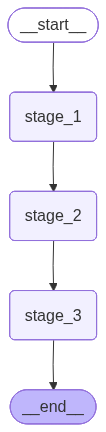

  stage_1: '  HELLO LangGraph  ' → '  hello langgraph  '
  stage_2: '  hello langgraph  ' → 'hello langgraph'
  stage_3: 'hello langgraph' → 'hello langgraph!'

최종 결과: 'hello langgraph!'


In [13]:
# 일반 엣지로 순차 파이프라인을 구성해요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class PipelineState(TypedDict):
    text: str  # 처리 과정을 추적하는 문자열


def stage_1(state: PipelineState):
    """1단계: 소문자 변환"""
    result = state["text"].lower()
    print(f"  stage_1: '{state['text']}' → '{result}'")
    return {"text": result}


def stage_2(state: PipelineState):
    """2단계: 공백 제거"""
    result = state["text"].strip()
    print(f"  stage_2: '{state['text']}' → '{result}'")
    return {"text": result}


def stage_3(state: PipelineState):
    """3단계: 느낌표 추가"""
    result = state["text"] + "!"
    print(f"  stage_3: '{state['text']}' → '{result}'")
    return {"text": result}


# 그래프 구성: START → stage_1 → stage_2 → stage_3 → END
builder = StateGraph(PipelineState)
builder.add_node("stage_1", stage_1)
builder.add_node("stage_2", stage_2)
builder.add_node("stage_3", stage_3)

# 일반 엣지 — 항상 이 순서대로 실행돼요
builder.add_edge(START, "stage_1")
builder.add_edge("stage_1", "stage_2")
builder.add_edge("stage_2", "stage_3")
builder.add_edge("stage_3", END)

graph = builder.compile()

# 그래프 흐름: START → stage_1 → stage_2 → stage_3 → END
# stage_1: 소문자 변환, stage_2: 공백 제거, stage_3: 느낌표 추가
display(Image(graph.get_graph().draw_mermaid_png()))
result = graph.invoke({"text": "  HELLO LangGraph  "})
print(f"\n최종 결과: '{result['text']}'")

### 4-2. 조건부 엣지 (Conditional Edge)

조건부 엣지는 **라우팅 함수(routing function)**의 반환값에 따라 다른 노드로 분기해요.

```python
builder.add_conditional_edges(
    source_node,       # 어느 노드 뒤에 조건 판단을 할지
    routing_function,  # 상태를 보고 문자열 키를 반환하는 함수
    {"키1": "노드A", "키2": "노드B"}  # 키 → 노드 매핑 (생략 가능)
)
```


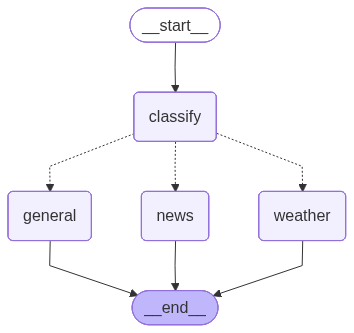

In [14]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class RouteState(TypedDict):
    query: str      # 사용자 질의
    category: str   # 분류 결과
    answer: str     # 최종 답변

def classify_node(state: RouteState):
    """질의를 분류하는 노드"""
    query = state["query"].lower()

    # 간단한 키워드 기반 분류예요
    if "날씨" in query:
        category = "weather"
    elif "뉴스" in query:
        category = "news"
    else:
        category = "general"
    print(f"  분류 결과: '{query}' → {category}")

    return {"category": category}

def weather_node(state: RouteState):
    """날씨 관련 질의 처리"""
    return {"answer": f"날씨 정보: {state['query']}에 대한 날씨는 맑음이에요."}  


def news_node(state: RouteState):
    """뉴스 관련 질의 처리"""
    return {"answer": f"뉴스 정보: {state['query']}에 대한 최신 뉴스예요."}


def general_node(state: RouteState):
    """일반 질의 처리"""
    return {"answer": f"일반 답변: {state['query']}에 대해 답변 드릴게요."}

def routing_function(state: RouteState):
    return state['category'] # Key 값.

# 그래프 구성
builder = StateGraph(RouteState)
builder.add_node("classify", classify_node)
builder.add_node("weather", weather_node)
builder.add_node("news", news_node)
builder.add_node("general", general_node)


builder.add_edge(START, "classify")

# 조건부 엣지  : classify 노드 이후에 조건부 엣지가 발동(routing_function)
builder.add_conditional_edges(
    "classify",
    routing_function,
    {
        "weather": "weather",
        "news": "news",
        "general": "general"
    }
)
builder.add_edge("weather", END)
builder.add_edge("news", END)
builder.add_edge("general", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# 세 가지 경로를 모두 테스트해요
test_queries = [
    "오늘 서울 날씨 어때요?",
    "오늘 뉴스 알려줘",
    "LangGraph가 뭐예요?"
]

for query in test_queries:
    result = graph.invoke({"query": query})
    print(f"답변: {result['answer']}")
    print()

  분류 결과: '오늘 서울 날씨 어때요?' → weather
답변: 날씨 정보: 오늘 서울 날씨 어때요?에 대한 날씨는 맑음이에요.

  분류 결과: '오늘 뉴스 알려줘' → news
답변: 뉴스 정보: 오늘 뉴스 알려줘에 대한 최신 뉴스예요.

  분류 결과: 'langgraph가 뭐예요?' → general
답변: 일반 답변: LangGraph가 뭐예요?에 대해 답변 드릴게요.



## 5. Send — 동적 병렬 처리

`Send`는 **하나의 노드에서 여러 노드 인스턴스를 병렬로 생성**하는 기능이에요. Map-Reduce 패턴을 구현할 때 특히 유용해요.

```mermaid
flowchart TB
    S([START]):::input
    GEN[generate_items<br/>항목 생성]:::process
    P1[process_item<br/>항목 1]:::process
    P2[process_item<br/>항목 2]:::process
    P3[process_item<br/>항목 3]:::process
    AGG[집계<br/>add 리듀서]:::storage
    E([END]):::output

    S --> GEN
    GEN -->|Send 1| P1
    GEN -->|Send 2| P2
    GEN -->|Send 3| P3
    P1 --> AGG
    P2 --> AGG
    P3 --> AGG
    AGG --> E

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

> 🔑 **핵심 개념**: `Send("노드이름", 개별_상태_딕셔너리)`로 각 병렬 인스턴스에 다른 State를 전달할 수 있어요. 결과는 `add` 리듀서를 통해 자동으로 병합돼요.


In [16]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# 전체 작업 상태
class BatchState(TypedDict):
    topics: list[str] # 처리할 주제의 목록
    results: Annotated[list[str], add] # 처리 결과 (add Reducer)

# 개별 작업 상태 : 세부적인 작업 상태. 즉 각 병렬 인스턴스(노드)가 받는 State
class SingleTopicState(TypedDict):
    topic: str

def prepare_topics(state: BatchState):
    # 실제 처리할 주제 목록을 준비하는 노드
    print(f" 처리할 주제 : {state['topics']}")
    return {} # 사용자가 설정한 주제에 대해서 아무런 처리를 하지 않음. 추후 질의에 증강이라던가, 질의에 대한 가드레일 설정 등을 수행 할 수 있음.

def process_single_topic(state: SingleTopicState):
    # 단일 주제를 처리하는 노드 (병렬로 여러 번 실행되는 노드)
    topic = state['topic']
    result = f"{topic}에 대한 처리가 완료되었습니다."
    print(f"  *병렬 처리 중 : {topic}")
    return {"results": [result]}

def dispatch_to_topics(state: BatchState):
    # 각 주제에 대해 Send를 생성하여 병렬 실행 트리거(시작)

    # 주제가 들어있는 리스트대로 병렬처리 Task를 만들거에요.
    return [
        Send("process_single_topic", {"topic": topic}) for topic in state['topics']
    ]

builder = StateGraph(BatchState)

# 노드 생성
builder.add_node("prepare", prepare_topics)
builder.add_node("process_single_topic", process_single_topic)

# 엣지 추가
builder.add_edge(START, "prepare")

# 조건부 엣지에서 Send 리스트를 반환하여 병렬처리를 시작.
builder.add_conditional_edges("prepare", dispatch_to_topics)

builder.add_edge("process_single_topic", END)

graph = builder.compile()

result = graph.invoke({
    "topics": ["파이썬", "LangGraph", "AI 에이전트"]
})

result

 처리할 주제 : ['파이썬', 'LangGraph', 'AI 에이전트']
  *병렬 처리 중 : 파이썬
  *병렬 처리 중 : AI 에이전트
  *병렬 처리 중 : LangGraph


{'topics': ['파이썬', 'LangGraph', 'AI 에이전트'],
 'results': ['파이썬에 대한 처리가 완료되었습니다.',
  'LangGraph에 대한 처리가 완료되었습니다.',
  'AI 에이전트에 대한 처리가 완료되었습니다.']}

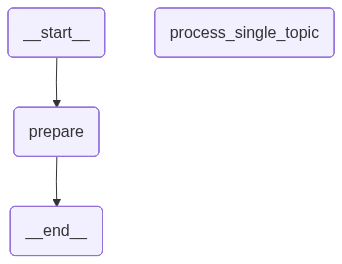

In [17]:
# 그래프 흐름: START → prepare → process_single_topic(병렬) → END
# prepare 노드: 처리할 주제 목록을 준비해요
# process_single_topic: Send API로 각 주제를 병렬 처리해요
# 결과는 add 리듀서로 자동 병합돼요
display(Image(graph.get_graph().draw_mermaid_png()))

## 6. Command — 상태 업데이트 + 라우팅 결합

`Command`는 **상태 업데이트와 다음 노드 지정을 하나의 반환값으로 처리**하는 방법이에요. 조건부 엣지를 별도로 정의하지 않고도 노드 내부에서 동적 라우팅을 할 수 있어요.

```python
from langgraph.types import Command

def my_node(state: State) -> Command:
    return Command(
        update={"field": "새 값"},  # State 업데이트
        goto="다음_노드"              # 다음에 실행할 노드
    )
```

| 구분 | 조건부 엣지 | Command |
|------|------------|---------|
| 라우팅 로직 위치 | 별도의 라우팅 함수 | 노드 내부 |
| 상태 업데이트 | 노드에서 반환 + 별도 라우팅 | 하나의 반환값으로 동시 처리 |
| 코드 간결성 | 함수 2개 필요 (노드 + 라우터) | 함수 1개로 충분 |
| 권장 상황 | 라우팅만 필요할 때 | 업데이트 + 라우팅이 결합될 때 |


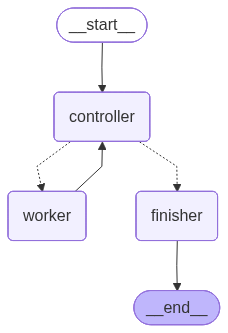

In [18]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

class LoopState(TypedDict):
    count: int
    status: str

def controller_node(state: LoopState) -> Command[Literal["worker", "finisher"]]:
    # 반복 횟수를 보고 worker 또는 finisher로 라우팅하는 노드
    #  Command의 타입 힌트 Literal["worker", "finisher"] : 컨트롤러 노드가 어디로 이동할 수 있는지 명시.
    new_count = state['count'] + 1
    print(f".   controller: count={new_count}")

    if new_count < 3:
        # count가 3 미만이면 worker노드로 이동
        return Command(
            update={"count": new_count, "status": f"반복 {new_count}회 진행 중...."},
            goto="worker"
        )
    else:
        # count가 3 이상이면 finisher 노드로 이동
        return Command(
            update={"count": new_count, "status": "완료"},
            goto="finisher"
        )

def worker_node(state: LoopState):
    """반복 작업을 수행하는 노드"""
    print(f"  worker: 작업 수행 (count={state['count']})")
    return {}  # 상태 변경 없이 controller로 돌아가요


def finisher_node(state: LoopState):
    """작업을 마무리하는 노드"""
    print(f"  finisher: 모든 작업 완료!")
    return {}

# 그래프 구성
builder = StateGraph(LoopState)
builder.add_node("controller", controller_node)
builder.add_node("worker", worker_node)
builder.add_node("finisher", finisher_node)

# 엣지 연결 (루프 연결)
builder.add_edge(START, "controller")
builder.add_edge("worker", "controller")
builder.add_edge("finisher", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
# 그래프 실행: count=0에서 시작해 3회 반복 후 종료
result = graph.invoke({"count": 0, "status": "시작"})
print(f"\n최종 상태: count={result['count']}, status='{result['status']}'")

.   controller: count=1
  worker: 작업 수행 (count=1)
.   controller: count=2
  worker: 작업 수행 (count=2)
.   controller: count=3
  finisher: 모든 작업 완료!

최종 상태: count=3, status='완료'


### 6-1. 비교: Command vs 조건부 엣지

위의 Command 예제와 **동일한 동작**을 조건부 엣지로도 구현할 수 있어요. 아래 코드에서 직접 비교해보세요.

| 상황 | 추천 방식 | 이유 |
|------|----------|------|
| 라우팅만 필요 (업데이트 없음) | **조건부 엣지** | 라우팅 함수 하나로 간결하게 처리돼요 |
| 업데이트 + 라우팅이 결합 | **Command** | 조건 중복 없이 하나의 반환값으로 처리해요 |
| 여러 노드가 같은 라우터 공유 | **조건부 엣지** | 라우팅 함수를 재사용할 수 있어요 |


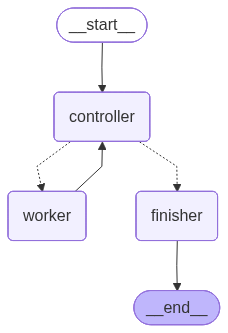

  controller: count=1
  worker: 작업 수행 (count=1)
  controller: count=2
  worker: 작업 수행 (count=2)
  controller: count=3
  finisher: 모든 작업 완료!

최종 상태: count=3, status='완료'



In [20]:
# 같은 루프 로직을 조건부 엣지로 구현해요 — Command 버전과 비교해보세요!
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class LoopStateCE(TypedDict):
    count: int
    status: str

# --- 노드 함수: 상태 업데이트만 담당해요 (분기 로직 없음!) ---
def controller_node_ce(state: LoopStateCE):
    """controller 노드: count만 증가시켜요. 분기 판단은 하지 않아요."""
    new_count = state["count"] + 1
    print(f"  controller: count={new_count}")
    return {"count": new_count}  # 순수하게 업데이트만!


# --- 라우팅 함수: 분기 판단만 담당해요 (상태 업데이트 없음!) ---
def routing_function(state: LoopStateCE) -> str:
    """별도의 라우팅 함수: 상태를 보고 다음 노드만 결정해요"""
    return "worker" if state["count"] < 3 else "finisher"


def worker_node_ce(state: LoopStateCE):
    """반복 작업을 수행하고 상태 메시지를 설정해요"""
    print(f"  worker: 작업 수행 (count={state['count']})")
    return {"status": f"반복 {state['count']}회 진행 중"}


def finisher_node_ce(state: LoopStateCE):
    """작업을 마무리하고 완료 상태를 설정해요"""
    print(f"  finisher: 모든 작업 완료!")
    return {"status": "완료"}


# 그래프 구성 — 조건부 엣지 사용
builder = StateGraph(LoopStateCE)
builder.add_node("controller", controller_node_ce)
builder.add_node("worker", worker_node_ce)
builder.add_node("finisher", finisher_node_ce)

builder.add_edge(START, "controller")

# Command 대신 add_conditional_edges로 라우팅을 정의해요
builder.add_conditional_edges(
    "controller",
    routing_function,  # 별도의 라우팅 함수가 필요해요
    {"worker": "worker", "finisher": "finisher"}
)
builder.add_edge("worker", "controller")  # worker → controller (루프)
builder.add_edge("finisher", END)

graph_ce = builder.compile()

# 그래프 흐름: START → controller → worker/finisher → ... → END
# controller: count만 증가 (분기 없음)
# routing_function: count를 보고 worker 또는 finisher로 분기해요
display(Image(graph_ce.get_graph().draw_mermaid_png()))

# 실행 — Command 버전과 동일한 결과가 나와요
# === 조건부 엣지 버전 실행 ===
result = graph_ce.invoke({"count": 0, "status": "시작"})
print(f"\n최종 상태: count={result['count']}, status='{result['status']}'")

print()
# 비교 포인트:
#   Command 버전  → controller_node 1개가 업데이트 + 라우팅을 동시에 처리
#   조건부 엣지 버전 → controller_node_ce(업데이트) + routing_function(분기) 2개로 분리
#   → 역할은 명확하게 나뉘지만, 코드가 더 길어져요

## 7. 재귀 제한 (Recursion Limit)

루프가 있는 그래프는 무한히 실행될 수 있어요. LangGraph는 `recursion_limit`으로 안전장치를 제공해요.

| 설정 | 기본값 | 동작 |
|------|--------|------|
| `recursion_limit=25` | 25 | 25번 노드 실행 후 `GraphRecursionError` 발생 |
| `recursion_limit=100` | - | 더 많은 반복 허용 |

```python
# config에서 재귀 제한을 설정해요
graph.invoke(inputs, config={"recursion_limit": 10})
```


In [21]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.errors import GraphRecursionError

class CountState(TypedDict):
    value: int

def increment(state: CountState) -> CountState:
    """값을 1씩 증가시키는 노드"""
    new_value = state["value"] + 1
    print(f"  현재 값: {new_value}")
    return {"value": new_value}

def should_stop(state: CountState) -> str:
    return "end" if state['value'] >= 50 else "continue"

builder = StateGraph(CountState)

builder.add_node("increment", increment)

builder.add_edge(START, "increment")
builder.add_conditional_edges(
    "increment",
    should_stop,
    {"continue": "increment", "end": END}
)

graph = builder.compile()

try:
    result = graph.invoke({"value": 0}, config={'recursion_limit': 7})
    print(result['value'])
except GraphRecursionError:
    print("반복 제한에 도달하였습니다. 그래프 실행을 중단합니다.")

  현재 값: 1
  현재 값: 2
  현재 값: 3
  현재 값: 4
  현재 값: 5
  현재 값: 6
  현재 값: 7
반복 제한에 도달하였습니다. 그래프 실행을 중단합니다.


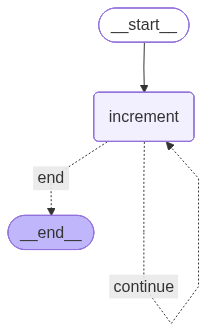

In [22]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 8. 다중 스키마 (Multiple Schemas)

그래프 전체에서 같은 State를 공유하는 것이 일반적이지만, 필요에 따라 **입력/출력 스키마를 분리**할 수 있어요.

| 방식 | 설명 | 사용 시점 |
|------|------|-----------|
| 단일 State | 그래프 전체가 같은 타입 사용 | 대부분의 경우 |
| `input_schema` / `output_schema` | 입출력 스키마 별도 정의 | API 서버, 외부에 노출하는 인터페이스 |
| 내부 State 분리 | 중간 계산에만 쓰는 필드 숨기기 | 민감한 중간 데이터 |


In [29]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# 외부에 노출할 입력 스키마
class InputSchema(TypedDict):
    question: str

# 내부 처리에서만 사용하고, 외부에는 노출하지 않을 스키마
class InternalState(TypedDict):
    question: str # 입력 받은 질문

    intermediate_result: str # 내부 중간 결과(외부에 노출하지 않음)

    answer:str # 최종 답변

class OutputSchema(TypedDict):
    answer: str # 최종 답변만 노출

def analyze_node(state: InternalState) -> InternalState:
    # 질문을 분석하는 노드 (중간 결과를 생성)
    intermediate = f"[내부 처리 로직] --> {state["question"]} 분석중....."
    return InternalState(intermediate_result=intermediate)
    # return {"intermediate_result": intermediate}

def answer_node(state: InternalState):
    # 최종 답변을 생성하는 노드
    answer = f"[최종 출력 로직] --> 질문 '{state['question']}' 에 대한 답변 생성함."
    return {"answer": answer}

# StateGraph에 input_schema / output_schema로 스키마를 지정한다. (LangGraph v1 api)
builder = StateGraph(
    InternalState,
    input_schema=InputSchema,
    output_schema=OutputSchema
)

# 노드 추가
builder.add_node("analyze", analyze_node)
builder.add_node("answer", answer_node)

# 엣지 연결
builder.add_edge(START, "analyze")
builder.add_edge("analyze", "answer")
builder.add_edge("answer", END)

graph = builder.compile()

result = graph.invoke({"question": "오늘의 날씨는 어때요?"})
result

{'answer': "[최종 출력 로직] --> 질문 '오늘의 날씨는 어때요?' 에 대한 답변 생성함."}

In [24]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → analyze → answer → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 9. 그래프 스트리밍 실행

`invoke()`는 최종 결과만 반환하지만, `stream()`은 **각 노드 실행 결과를 실시간으로 받을 수 있어요**.

| 모드 | 설명 | 사용 시점 |
|------|------|-----------|
| `stream_mode="updates"` | 각 노드가 업데이트한 State 변경분 | 노드별 진행 상황 추적 |
| `stream_mode="values"` | 각 노드 실행 후 전체 State | 전체 State 스냅샷 필요 시 |


In [31]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class StreamState(TypedDict):
    text: str

def step1(state: StreamState):
    return {"text": state["text"] + " [1단계 완료]"}

def step2(state: StreamState):
    return {"text": state["text"] + " [2단계 완료]"}

def step3(state: StreamState):
    return {"text": state["text"] + " [3단계 완료]"}

builder = StateGraph(StreamState)
builder.add_node("step1", step1)
builder.add_node("step2", step2)
builder.add_node("step3", step3)

builder.add_edge(START, "step1")
builder.add_edge("step1", "step2")
builder.add_edge("step2", "step3")
builder.add_edge("step3", END)

stream_graph = builder.compile()

# stream_mode = 'updates' : 각 노드의 변경분
for chunk in stream_graph.stream({"text": "시작"}, stream_mode="updates"):
    print(chunk)

print()

for chunk in stream_graph.stream({"text": "시작"}, stream_mode="values"):
    print(chunk)

{'step1': {'text': '시작 [1단계 완료]'}}
{'step2': {'text': '시작 [1단계 완료] [2단계 완료]'}}
{'step3': {'text': '시작 [1단계 완료] [2단계 완료] [3단계 완료]'}}

{'text': '시작'}
{'text': '시작 [1단계 완료]'}
{'text': '시작 [1단계 완료] [2단계 완료]'}
{'text': '시작 [1단계 완료] [2단계 완료] [3단계 완료]'}


In [26]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → step1 → step2 → step3 → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 10. 종합 실습

지금까지 배운 내용을 종합해서 **텍스트 처리 파이프라인**을 만들어봐요. 입력 텍스트의 언어를 감지하고, 언어에 따라 다른 처리 경로로 분기해요.


In [27]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END

# ============================================================
# TODO: 아래 라우팅 함수를 완성해보세요!
# 힌트: state["language"] 값이 "ko"이면 "korean", "en"이면 "english",
#       그 외에는 "other"를 반환해요
# 예상 결과: 한국어 입력 → korean_handler, 영어 입력 → english_handler
# ============================================================

    # TODO: 여기를 완성해보세요
    # state["language"]가 "ko"이면 "korean",
    # "en"이면 "english", 그 외는 "other"를 반환하면 돼요


In [28]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 테스트 실행
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **StateGraph**: `TypedDict`로 State를 정의하고, `add_node()` / `add_edge()`로 조립한 뒤 `compile()`로 실행 가능한 그래프를 생성해요
- **리듀서(Reducer)**: `Annotated[타입, 리듀서함수]`로 State 필드의 업데이트 방식을 결정해요. 기본은 덮어쓰기, `operator.add`는 리스트 누적, `add_messages`는 메시지 ID 기반 병합이에요
- **일반 엣지**: `add_edge(source, target)`으로 항상 고정된 경로를 정의해요
- **조건부 엣지**: `add_conditional_edges(source, routing_fn, path_map)`으로 상태 기반 동적 분기를 구현해요
- **Send**: 조건부 엣지에서 `Send` 리스트를 반환하면 여러 노드 인스턴스를 병렬로 실행해요 (Map-Reduce 패턴)
- **Command**: `Command(update=..., goto=...)`로 상태 업데이트와 라우팅을 하나의 반환값으로 처리해요
- **재귀 제한**: `config={"recursion_limit": N}`으로 무한 루프를 방지하고, 한도 초과 시 `GraphRecursionError`가 발생해요
- **스트리밍**: `stream(mode="updates")`로 각 노드의 실행 결과를 실시간으로 받을 수 있어요


## 다음 노트북 예고

다음 `05-ChatBot.ipynb`에서는 **StateGraph에 실제 LLM을 연결해 대화형 챗봇**을 만들어요. 이 노트북에서 배운 `StateGraph`, `add_messages` 리듀서, `MessagesState`를 모두 활용해서 대화 이력을 유지하는 챗봇을 구현할 거예요.
